In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Use the absolute path to your Downloads folder
df = pd.read_csv(r'C:\Users\Goutham\Downloads\assignment-2 1\data\load_data.csv')

# Use the correct column name and handle datetime parsing
df['Date_Time'] = pd.to_datetime(df['Date_Time'], dayfirst=True, errors='coerce')

# Drop unparseable dates and sort chronologically
df = df.dropna(subset=['Date_Time'])
df = df.sort_values(by='Date_Time').reset_index(drop=True)

print(df.info())
display(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35041 entries, 0 to 35040
Data columns (total 9 columns):
 #   Column                                Non-Null Count  Dtype         
---  ------                                --------------  -----         
 0   Date_Time                             35041 non-null  datetime64[ns]
 1   Usage_kWh                             33482 non-null  float64       
 2   Lagging_Current_Reactive.Power_kVarh  34165 non-null  float64       
 3   Leading_Current_Reactive_Power_kVarh  33885 non-null  float64       
 4   CO2(tCO2)                             34586 non-null  float64       
 5   Lagging_Current_Power_Factor          34691 non-null  float64       
 6   Leading_Current_Power_Factor          33570 non-null  float64       
 7   NSM                                   34586 non-null  float64       
 8   Load_Type                             35041 non-null  object        
dtypes: datetime64[ns](1), float64(7), object(1)
memory usage: 2.4+ MB
None


,Date_Time,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,Load_Type
0,2018-01-01 00:00:00,3.420000,3.46,0.0,0.0,70.30,291.49819,0.000000,Light_Load
1,2018-01-01 00:15:00,8.753692,2.95,0.0,0.0,73.21,100.00000,900.000000,Light_Load
2,2018-01-01 00:30:00,4.000000,4.46,0.0,0.0,66.77,100.00000,1800.000000,Light_Load
3,2018-01-01 00:45:00,3.240000,3.28,0.0,0.0,70.28,100.00000,8070.880991,Light_Load
4,2018-01-01 01:00:00,3.310000,3.56,0.0,0.0,68.09,100.00000,3600.000000,Light_Load


In [5]:
pip install "numpy<2"

Note: you may need to restart the kernel to use updated packages.


In [7]:
df = pd.read_csv(r'C:\Users\Goutham\Downloads\assignment-2 1\data\load_data.csv')

Missing values after imputation:
 Date_Time                               0
Usage_kWh                               0
Lagging_Current_Reactive.Power_kVarh    0
Leading_Current_Reactive_Power_kVarh    0
CO2(tCO2)                               0
Lagging_Current_Power_Factor            0
Leading_Current_Power_Factor            0
NSM                                     0
Load_Type                               0
dtype: int64
------------------------------
Target Variable Encoding Mapping: {'Light_Load': 0, 'Maximum_Load': 1, 'Medium_Load': 2}


C:\Users\Goutham\AppData\Local\Temp\ipykernel_1896\1650889377.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Load_Type', palette='viridis')


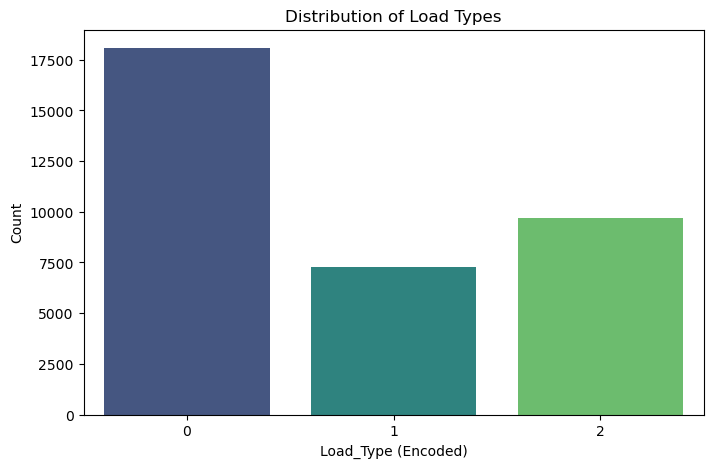

In [9]:
from sklearn.preprocessing import LabelEncoder
df = df.fillna(df.median(numeric_only=True))
print("Missing values after imputation:\n", df.isnull().sum())
print("-" * 30)
le = LabelEncoder()
df['Load_Type'] = le.fit_transform(df['Load_Type'])
encoding_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("Target Variable Encoding Mapping:", encoding_mapping)
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Load_Type', palette='viridis')
plt.title('Distribution of Load Types')
plt.xlabel('Load_Type (Encoded)')
plt.ylabel('Count')
plt.show()

In [11]:
df['Date_Time'] = pd.to_datetime(df['Date_Time'], dayfirst=True, errors='coerce')
df = df.dropna(subset=['Date_Time'])
max_date = df['Date_Time'].max()
last_month = max_date.month
last_year = max_date.year

print(f"Dataset ends in: {max_date.strftime('%B %Y')}")
test_mask = (df['Date_Time'].dt.month == last_month) & (df['Date_Time'].dt.year == last_year)

train_df = df[~test_mask]
test_df = df[test_mask]
X_train = train_df.drop(columns=['Date_Time', 'Load_Type'])
y_train = train_df['Load_Type']

X_test = test_df.drop(columns=['Date_Time', 'Load_Type'])
y_test = test_df['Load_Type']

print(f"Training Features Shape: {X_train.shape}")
print(f"Testing Features Shape: {X_test.shape}")

Dataset ends in: December 2018
Training Features Shape: (32064, 7)
Testing Features Shape: (2977, 7)


In [13]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)

y_pred = rf_model.predict(X_test_scaled)

print(f"Overall Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")

target_names = ['Light_Load', 'Maximum_Load', 'Medium_Load']
print("Detailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=target_names))

Overall Accuracy: 72.52%

Detailed Classification Report:
              precision    recall  f1-score   support

  Light_Load       0.96      0.88      0.92      1745
Maximum_Load       0.42      0.46      0.44       528
 Medium_Load       0.47      0.53      0.50       704

    accuracy                           0.73      2977
   macro avg       0.62      0.63      0.62      2977
weighted avg       0.75      0.73      0.74      2977



Encoding Mapping: {0: 0, 1: 1, 2: 2}


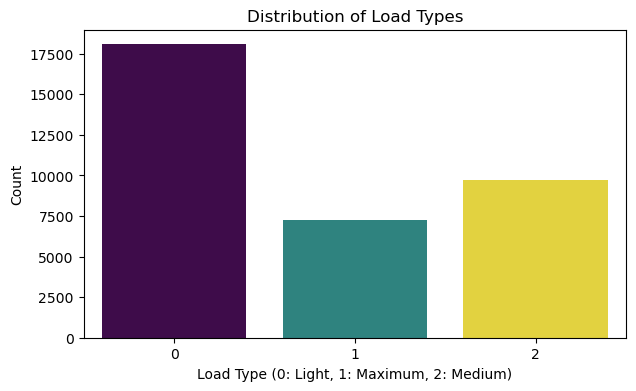

In [15]:
from sklearn.preprocessing import LabelEncoder

df = df.fillna(df.median(numeric_only=True))

le = LabelEncoder()
df['Load_Type'] = le.fit_transform(df['Load_Type'])
encoding_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("Encoding Mapping:", encoding_mapping)
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x='Load_Type', hue='Load_Type', palette='viridis', legend=False)
plt.title('Distribution of Load Types')
plt.xlabel('Load Type (0: Light, 1: Maximum, 2: Medium)')
plt.ylabel('Count')
plt.show()

In [17]:
max_date = df['Date_Time'].max()
last_month = max_date.month
last_year = max_date.year

test_mask = (df['Date_Time'].dt.month == last_month) & (df['Date_Time'].dt.year == last_year)

train_df = df[~test_mask]
test_df = df[test_mask]

X_train = train_df.drop(columns=['Date_Time', 'Load_Type'])
y_train = train_df['Load_Type']

X_test = test_df.drop(columns=['Date_Time', 'Load_Type'])
y_test = test_df['Load_Type']

print(f"Train samples: {X_train.shape[0]} | Test samples: {X_test.shape[0]}")

Train samples: 32064 | Test samples: 2977


In [19]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)
y_pred = rf_model.predict(X_test_scaled)
print(f"Overall Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")
print(classification_report(y_test, y_pred, target_names=['Light_Load', 'Maximum_Load', 'Medium_Load']))

Overall Accuracy: 72.52%

              precision    recall  f1-score   support

  Light_Load       0.96      0.88      0.92      1745
Maximum_Load       0.42      0.46      0.44       528
 Medium_Load       0.47      0.53      0.50       704

    accuracy                           0.73      2977
   macro avg       0.62      0.63      0.62      2977
weighted avg       0.75      0.73      0.74      2977



C:\Users\Goutham\AppData\Local\Temp\ipykernel_1896\165847951.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette='mako')


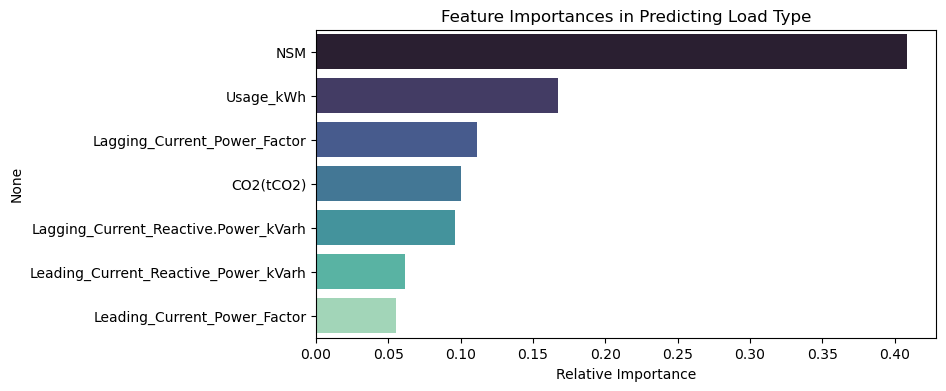

In [21]:
importances = pd.Series(rf_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(x=importances.values, y=importances.index, palette='mako')
plt.title('Feature Importances in Predicting Load Type')
plt.xlabel('Relative Importance')
plt.show()